In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker


In [2]:
pisa = pd.read_stata("data/PISA_TREE1_2000_version_2025.dta")
waves = {}
for i in range(1,8):
    filename = f"data/TREE1_data_wave_{i}_{2000+i}_version_2025.dta"
    waves[i] = pd.read_stata(filename)
waves[8] = pd.read_stata("data/TREE1_data_wave_8_2010_version_2025.dta")
waves[9] = pd.read_stata("data/TREE1_data_wave_9_2014_version_2025.dta")
waves[10] = pd.read_stata("data/TREE1_data_wave_10_2019_version_2025.dta")

C:\Users\ethan\AppData\Local\Temp\ipykernel_18076\1821140613.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  pisa = pd.read_stata("data/PISA_TREE1_2000_version_2025.dta")


# Education Type and Employment Satisfaction

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',None)
job_sat_clean = {}
for i in range(1, 11):
    df = waves[i][waves[i].iloc[:, 3].str.strip() != 'not valid'].copy()
    
    educ22_cols = [col for col in df.columns if col.startswith(f"t{i}educ22_1")]
    jsag_cols   = [col for col in df.columns if col.startswith(f"t{i}jsag1")]
    
    cols_to_keep = ['id'] + educ22_cols + jsag_cols  # <-- id retained
    cols_to_keep = [c for c in cols_to_keep if c in df.columns]
    
    df = df[cols_to_keep]
    df = df.rename(columns=lambda col: col.replace(f"t{i}", "t") if col != 'id' else col)
    df['wave'] = i  # <-- track which wave each row came from
    
    job_sat_clean[i] = df

job_sat_long = pd.concat(
    [job_sat_clean[i] for i in range(1, 11)],
    ignore_index=True
)
    # EDUC22: Current status of education, 23 levels of categories
    # JSAG: In general, how satisfied are you with your current work?


In [4]:
#Cleaning amount of categories


#Making less categories,but ones that all fall under the same type
educ22_map = {
    
    'apprenticeship with federal diploma of vocational education and training, or equivalent (3 or 4 years)': 'VET apprenticeship',
    'apprenticeship with federal diploma of vocational education and training (Eidgenössisches Fähigkeitszeugnis) or equivalent (3 or 4 years)': 'VET apprenticeship',
    'apprenticeship with basic federal certificate of vocational education and training (2years)(Berufsattest)': 'VET apprenticeship',
    'commercial college (WMS)': 'VET apprenticeship',

    
    'higher vocational education and training (Advanced Federal Certificate/Federal Diploma of Higher VET)': 'Higher VET',
    'higher specialised school': 'Higher VET',
    'professional baccalaureate/vocational matura (full time after education)': 'Higher VET',

    
    'universities and federal institutes of technology (ETH)(Bachelor/Master/Diploma)': 'University',
    'universities and federal institutes of technology (ETH) (Bachelor/Master/Diploma)': 'University',
    'university of applied sciences/universities of teacher education (Bachelor)': 'University',
    'postgraduate studies': 'University',
    'post-graduate studies': 'University',
    'PhD': 'University',
    'Professional academic specialisation / examination': 'University',
    'Professional academic specialisation/examination': 'University',
    'teachers college (kindergarten/primary)': 'University',

    
    'academic matura school': 'General upper secondary',
    'specialised middle schools (FMS/DMS)': 'General upper secondary',
    'specialised matura (FMS/DMS)': 'General upper secondary',
    'pre-course (in order to enter higher education)': 'General upper secondary',

  
    'other education': 'Other',
    'courses to bridge gaps in training': 'Other',
    'preapprenticeship': 'Other',
    'internship (not part of education)': 'Other',
    'language stay, Au-Pair': 'Other',
}

job_sat_long['educ_path'] = job_sat_long['teduc22_1'].map(educ22_map)

jsag_map = {
    'extraordinarily satisfied': 6,
    'very satisfied':             5,
    'rather satisfied':           4,
    'so, so':                     3,
    'rather dissatisfied':        2,
    'very dissatisfied':          1,
    'extraordinarily dissatisfied': 0,
}


###BEGIN AI USE
def recode_jsag(val):
    if pd.isna(val):
        return np.nan
    if val in jsag_map:
        return jsag_map[val]
        
    try:
        return round(float(val))
    except:
        return np.nan
        
job_sat_long['jsag_score'] = job_sat_long['tjsag1'].apply(recode_jsag)

###END AI USE

educ_path_per_person = (
    job_sat_long[job_sat_long['educ_path'].notna()]
    .groupby('id')['educ_path']
    .agg(lambda x: x.value_counts().index[0])  # modal path
    .reset_index()
    .rename(columns={'educ_path': 'primary_educ_path'})
)

has_jsag = job_sat_long[job_sat_long['jsag_score'].notna()][['id', 'wave', 'jsag_score']]
analysis_df = has_jsag.merge(educ_path_per_person, on='id')

plot_df = analysis_df[analysis_df['primary_educ_path'] != 'Other'].copy()


# Education Type and Wantingness to Resign

In [5]:
jsar_clean = {}
for i in range(1, 11):
    df = waves[i][waves[i].iloc[:, 3].str.strip() != 'not valid'].copy()
    
    jsar_cols = [col for col in df.columns if col.startswith(f"t{i}jsar1")]
    
    cols_to_keep = ['id'] + jsar_cols
    cols_to_keep = [c for c in cols_to_keep if c in df.columns]
    
    df = df[cols_to_keep]
    df = df.rename(columns=lambda col: col.replace(f"t{i}", "t") if col != 'id' else col)
    df['wave'] = i
    
    jsar_clean[i] = df

jsar_long = pd.concat([jsar_clean[i] for i in range(1, 11)], ignore_index=True)

#print(jsar_long['tjsar1'].unique())

In [6]:
jsar_map = {
    'hardly ever':          1,
    'very scarcely':        2,
    'rather scarcely':      3,
    'every now and then':   4,
    ' every now and then':  4,
    'rather often':         5,
    'very often':           6,
    'almost ever':          7,
    'extraordinarily satisfied': 1,
    'very satisfied':            2,
    'rather satisfied':          3,
    'so, so':                    4,
    'rather dissatisfied':       5,
    'very dissatisfied':         6,
    'extraordinarily dissatisfied': 7,
}

#BEGIN AI USE
def recode_jsar(val):
    if pd.isna(val):
        return np.nan
    if val in jsar_map:
        return jsar_map[val]
    try:
        return round(float(val))
    except:
        return np.nan

jsar_long['jsar_score'] = jsar_long['tjsar1'].apply(recode_jsar)


#print(jsar_long['jsar_score'].value_counts(dropna=False))

# Visualization of Data

NameError: name 'paths_ordered' is not defined

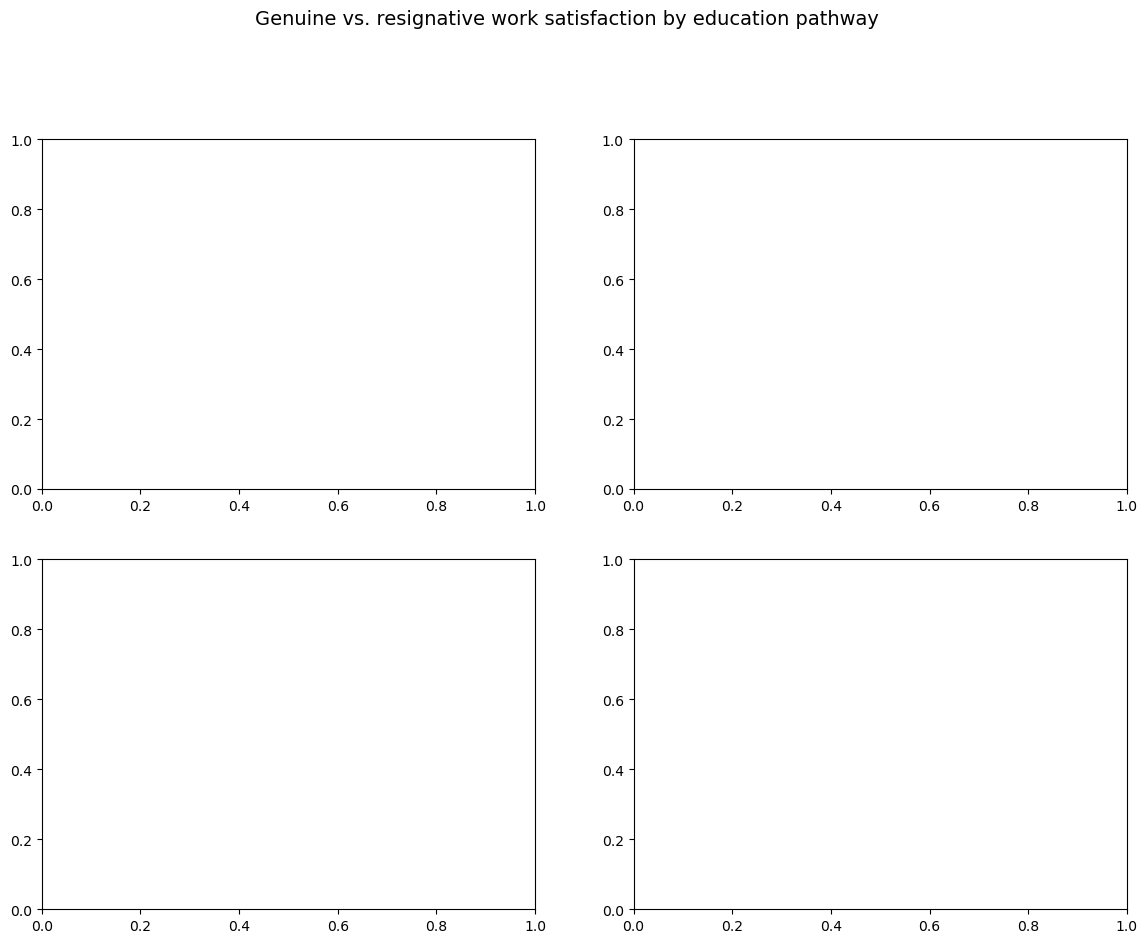

In [7]:
#BEGIN AI USE
# Exclude wave 10 from jsar entirely
jsar_long_clean = jsar_long[jsar_long['wave'] != 10].copy()
jsar_long_clean['jsar_score'] = jsar_long_clean['tjsar1'].apply(recode_jsar)
#END AI USE

n_label_y_jsag = {
    'VET apprenticeship':       4.55,
    'General upper secondary':  4.45,
    'University':               4.35,
    'Higher VET':               4.65,
}
n_label_y_jsar = {
    'VET apprenticeship':       2.70,
    'General upper secondary':  2.62,
    'University':               2.54,
    'Higher VET':               2.78,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Genuine vs. resignative work satisfaction by education pathway',
             fontsize=14, fontweight='500', y=1.01)

for col_idx, (score, title, yticks, ylabels) in enumerate([
    ('jsag_score', 'Genuine satisfaction (jsag)',
     [0, 3, 6], ['0\n(extraord.\ndissatisfied)', '3\n(so-so)', '6\n(extraord.\nsatisfied)']),
    ('jsar_score', 'Resignative satisfaction (jsar)',
     [1, 4, 7], ['1\n(hardly ever\nresigned)', '4\n(every now\nand then)', '7\n(almost\never)']),
]):
    ax = axes[0][col_idx]
    plot_data = [plot_df2[plot_df2['primary_educ_path'] == p][score].dropna()
                 for p in paths_ordered]
    vp = ax.violinplot(plot_data, positions=range(len(paths_ordered)),
                       showmedians=True, showextrema=False)
    for body, color in zip(vp['bodies'], colors):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    vp['cmedians'].set_color('white')
    vp['cmedians'].set_linewidth(2)
    ax.set_xticks(range(len(paths_ordered)))
    ax.set_xticklabels(['VET', 'General\nupper sec.', 'University', 'Higher\nVET'], fontsize=10)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

for col_idx, (score, title, ylim, n_label_y) in enumerate([
    ('jsag_mean', 'Genuine satisfaction over time', (3.5, 5.5), n_label_y_jsag),
    ('jsar_mean', 'Resignative satisfaction over time', (2.0, 5.0), n_label_y_jsar),
]):
    ax = axes[1][col_idx]
    for path in paths_ordered:
        subset = wave_summary2[wave_summary2['primary_educ_path'] == path]
        subset = subset[subset['n'] >= 10]
        ax.plot(subset['wave'], subset[score],
                marker='o', markersize=5, linewidth=2,
                color=path_colors[path], label=path)
        last = subset.iloc[-1]
        ax.annotate(f"n={int(last['n'])}",
                    xy=(last['wave'], last[score]),
                    xytext=(last['wave'] + 0.2, n_label_y[path]),
                    fontsize=8, color=path_colors[path])
    ax.set_xticks(list(wave_labels.keys()))
    ax.set_xticklabels(list(wave_labels.values()), fontsize=10, rotation=30)
    ax.set_ylabel('Mean score', fontsize=10)
    ax.set_ylim(ylim)
    ax.set_title(title, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('genuine_vs_resignative_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()

person_avg = (
    plot_df2.groupby(['id', 'primary_educ_path'])
    .agg(jsag_mean=('jsag_score', 'mean'),
         jsar_mean=('jsar_score', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True, sharex=True)
fig.suptitle('Genuine vs. resignative satisfaction per person by pathway',
             fontsize=14, fontweight='500', y=1.01)

for ax, path in zip(axes, paths_ordered):
    subset = person_avg[person_avg['primary_educ_path'] == path]
    ax.scatter(subset['jsag_mean'], subset['jsar_mean'],
               color=path_colors[path], alpha=0.3, s=15)
    ax.axvline(subset['jsag_mean'].mean(), color='gray', linewidth=0.8, linestyle='--')
    ax.axhline(subset['jsar_mean'].mean(), color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(path.replace(' ', '\n'), fontsize=10)
    ax.set_xlabel('Genuine satisfaction', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.2)

axes[0].set_ylabel('Resignative satisfaction', fontsize=9)
plt.tight_layout()
plt.savefig('scatter_genuine_vs_resignative.png', dpi=150, bbox_inches='tight')
plt.show()